# 05 — Building and electricity-context sensitivity

This experiment tests whether the relative performance of the existing decision strategies changes when the **building context** or **electricity decarbonization pathway** changes.

Three version folders are compared:

- **Reference residential** — `Versionen/paper_draft_v1`
- **Partly renovated office** — `Versionen/office_building`  
  Partly renovated starting state with higher electricity demand.
- **High-carbon electricity** — `Versionen/high_carbon_electricity`  
  Reference building with higher grid-emission factors and slower electricity decarbonization.

The gameplay rule is held fixed at the same setting as the strategy-comparison experiment:

- `random_draw`
- 20 offered cards per decision
- `pass_probability = 0.05`

The main question is not whether absolute VP differs between contexts — that is expected — but whether **strategy rankings and relative strategy advantages change**. A change in ranking would provide direct evidence that preferred renovation pathways depend on the initial building and energy-system context.

Only completed four-round games are used for final-state comparisons. Premature games are retained for completion-rate analysis.

## 1. Setup

The notebook deliberately uses the existing `model.simulate`, `model.game`, `model.analysis`, and `model.plotting` interfaces rather than duplicating game logic.

Strategy modules are loaded dynamically from `model.strategies.<name>`. If a strategy module has a different filename, only the `STRATEGY_MODULES` dictionary below needs to be changed.

In [74]:
%load_ext autoreload
%autoreload 2

from importlib import import_module
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

from model.game import load_game_data, new_game
from model.simulate import run_simulation
from model.analysis import card_analysis
from model.plotting import configure_plots, save_figure

configure_plots()

VERSION_PATHS = {
    "reference": Path("Versionen/paper_draft_v1"),
    "office": Path("Versionen/office_building"),
    "high-carbon electricity": Path("Versionen/high_carbon_electricity"),
}

VERSION_LABELS = {
    "reference": "Reference residential",
    "office": "Partly renovated office",
    "high-carbon electricity": "High-carbon electricity",
}

STRATEGY_MODULES = {
    "random": "random",
    "electrician": "electrician",
    "decarbonizer": "off_gas",
    "insulator": "insulator",
    "people pleaser": "people_pleaser",
}

STRATEGIES = {
    name: import_module(
        f"model.strategies.{module}"
    ).choose_card
    for name, module in STRATEGY_MODULES.items()
}

N_GAMES = 10_000
RULE = "random_draw"
DRAW_N = 10
PASS_PROBABILITY = 0.05
SEED = 42

RUN_SIMULATIONS = True
SAVE_FIGURES = False

EXPERIMENT_DIR = (
    VERSION_PATHS["reference"]
    / "results"
    / "context_sensitivity"
)
FIGURE_DIR = EXPERIMENT_DIR / "figures"

GAMES_PATH = EXPERIMENT_DIR / "all_games.parquet"
CARD_RESULTS_PATH = EXPERIMENT_DIR / "random_strategy_card_results.parquet"

for path in VERSION_PATHS.values():
    assert path.exists(), f"Missing version folder: {path}"

EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)

print(
    f"{len(VERSION_PATHS)} contexts × "
    f"{len(STRATEGIES)} strategies × "
    f"{N_GAMES:,} games = "
    f"{len(VERSION_PATHS) * len(STRATEGIES) * N_GAMES:,} simulations"
)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
3 contexts × 5 strategies × 10,000 games = 150,000 simulations


## 2. Verify what changed between versions

Before interpreting simulation results, inspect the actual starting-state and board-parameter differences.

The first table compares scalar starting-state values created by `new_game()`. The second reports board-level values that differ from the reference version. This provides a compact audit trail for the experiment and helps catch unintended changes between version folders.

In [75]:
game_data_by_version = {
    version: load_game_data(path)
    for version, path in VERSION_PATHS.items()
}

reference = game_data_by_version["reference"]["board"]

differences = []

for version, game_data in game_data_by_version.items():
    if version == "reference":
        continue

    board = game_data["board"]

    for key in reference:
        ref = reference[key]
        other = board[key]

        if ref != other:
            differences.append({
                "version": version,
                "parameter": key,
                "reference": ref,
                "scenario": other,
            })

pd.DataFrame(differences)

,version,parameter,reference,scenario
0,office,demand_grid,"[4, 5, 6, 7, 8, 9, 10, 11, 12, 13]","[7, 8, 9, 10, 11, 12, 13, 14, 15, 16]"
1,office,heating_vp,"[[200, 180, 160, 140, 120, 100, 80, 60, 40, 20...","[[100, 90, 80, 70, 60, 50, 40, 30, 20, 10], [2..."
2,office,heating_budget,"[[0, 0, 1, 1, 2, 2, 2, 3, 3, 4], [1, 1, 1, 2, ...","[[0, 0, 1, 1, 1, 1, 2, 2, 2, 2], [0, 0, 1, 1, ..."
3,office,hp_grid,"[[18, 16, 14, 12, 10, 8, 6, 4, 2, 0], [14, 13,...","[[9, 8, 7, 6, 5, 4, 3, 2, 1, 0], [7, 6, 6, 5, ..."
4,high-carbon electricity,demand_start,4,5
5,high-carbon electricity,grid_vp,"[[0, 2, 5, 8, 10, 12, 15, 18, 20, 22, 25, 28, ...","[[0, 8, 15, 23, 30, 38, 45, 53, 60, 68, 75, 83..."


In [76]:
game_data_by_version["high-carbon electricity"]["board"]["grid_vp"]

[[0,
  8,
  15,
  23,
  30,
  38,
  45,
  53,
  60,
  68,
  75,
  83,
  90,
  98,
  105,
  113,
  120,
  128,
  135,
  143,
  150,
  158,
  165,
  173,
  180,
  188,
  195,
  203,
  210,
  218,
  225,
  233,
  240,
  248,
  255,
  263],
 [0,
  5,
  10,
  15,
  20,
  25,
  30,
  35,
  40,
  45,
  50,
  55,
  60,
  65,
  70,
  75,
  80,
  85,
  90,
  95,
  100,
  105,
  110,
  115,
  120,
  125,
  130,
  135,
  140,
  145,
  150,
  155,
  160,
  165,
  170,
  175],
 [0,
  4,
  8,
  11,
  15,
  19,
  23,
  26,
  30,
  34,
  38,
  41,
  45,
  49,
  53,
  56,
  60,
  64,
  68,
  71,
  75,
  79,
  83,
  86,
  90,
  94,
  98,
  101,
  105,
  109,
  113,
  116,
  120,
  124,
  128,
  131],
 [0,
  3,
  5,
  8,
  10,
  13,
  15,
  18,
  20,
  23,
  25,
  28,
  30,
  33,
  35,
  38,
  40,
  43,
  45,
  48,
  50,
  53,
  55,
  58,
  60,
  63,
  65,
  68,
  70,
  73,
  75,
  78,
  80,
  83,
  85,
  88]]

In [77]:
# The experiment assumes the same intervention set in all contexts.
# Warn rather than fail if this is not the case.

def logical_card_ids(game_data):
    cards = pd.DataFrame(game_data["cards"])
    column = "card_id" if "card_id" in cards.columns else "id"
    return set(cards[column].dropna())

reference_cards = logical_card_ids(
    game_data_by_version["reference"]
)

for version, game_data in game_data_by_version.items():
    cards = logical_card_ids(game_data)

    print(
        version,
        f"{len(cards)} logical cards",
        "same card set" if cards == reference_cards else "DIFFERENT card set",
    )


reference 56 logical cards same card set
office 56 logical cards same card set
high-carbon electricity 56 logical cards same card set


## 3. Run the experiment

Each version is simulated with each strategy under identical rule parameters.

The same seed is reused for a given strategy across version folders. This does not make trajectories perfectly paired once game states diverge, but it keeps the random-number initialization consistent across contexts.

`run_simulation(..., save=False)` is used so that individual conditions do not overwrite each other's default result files. The combined experiment is saved once at the end.

In [78]:
if RUN_SIMULATIONS:

    all_results = []

    for strategy_i, (strategy_name, strategy) in enumerate(
        STRATEGIES.items()
    ):
        strategy_seed = SEED + strategy_i

        for version, version_path in VERSION_PATHS.items():

            print()
            print("=" * 70)
            print(
                VERSION_LABELS[version],
                "|",
                strategy_name,
            )
            print("=" * 70)

            games, _ = run_simulation(
                version_path,
                n_games=N_GAMES,
                strategy=strategy,
                strategy_name=strategy_name,
                rule=RULE,
                draw_n=DRAW_N,
                pass_probability=PASS_PROBABILITY,
                seed=strategy_seed,
                save=False,
                log_choices=False,
            )

            games["version"] = version
            games["version_label"] = VERSION_LABELS[version]

            all_results.append(games)

    all_games_raw = pd.concat(
        all_results,
        ignore_index=True,
    )

    all_games_raw.to_parquet(
        GAMES_PATH,
        index=False,
    )

else:
    all_games_raw = pd.read_parquet(GAMES_PATH)

print()
print(f"{len(all_games_raw):,} simulated games loaded")



Reference residential | random
10,000/10,000 games | 4,251 games/s

Partly renovated office | random
10,000/10,000 games | 5,698 games/s

High-carbon electricity | random
10,000/10,000 games | 5,076 games/s

Reference residential | electrician
10,000/10,000 games | 3,238 games/s

Partly renovated office | electrician
10,000/10,000 games | 4,138 games/s

High-carbon electricity | electrician
10,000/10,000 games | 4,302 games/s

Reference residential | decarbonizer
10,000/10,000 games | 4,917 games/s

Partly renovated office | decarbonizer
10,000/10,000 games | 4,679 games/s

High-carbon electricity | decarbonizer
10,000/10,000 games | 4,908 games/s

Reference residential | insulator
10,000/10,000 games | 3,488 games/s

Partly renovated office | insulator
10,000/10,000 games | 3,844 games/s

High-carbon electricity | insulator
10,000/10,000 games | 3,704 games/s

Reference residential | people pleaser
10,000/10,000 games | 2,996 games/s

Partly renovated office | people pleaser
10,000/1

## 4. Comparable population and consistency checks

Final VP and final-state metrics are compared only among completed games. Completion itself is analyzed separately because running out of budget is part of the game dynamics.

In [79]:
settings_columns = [
    column
    for column in [
        "version",
        "strategy",
        "rule",
        "draw_n",
        "pass_probability",
    ]
    if column in all_games_raw.columns
]

display(
    all_games_raw[
        settings_columns
    ]
    .drop_duplicates()
    .sort_values(["version", "strategy"])
)

all_games = all_games_raw.loc[
    all_games_raw["completed"]
].copy()

print(f"{len(all_games_raw):,} simulated games")
print(f"{len(all_games):,} completed games")
print(f"{len(all_games) / len(all_games_raw):.1%} overall completion")


,version,strategy,rule,draw_n,pass_probability
80000,high-carbon electricity,decarbonizer,random_draw,10,0.05
50000,high-carbon electricity,electrician,random_draw,10,0.05
110000,high-carbon electricity,insulator,random_draw,10,0.05
140000,high-carbon electricity,people pleaser,random_draw,10,0.05
20000,high-carbon electricity,random,random_draw,10,0.05
70000,office,decarbonizer,random_draw,10,0.05
40000,office,electrician,random_draw,10,0.05
100000,office,insulator,random_draw,10,0.05
130000,office,people pleaser,random_draw,10,0.05
10000,office,random,random_draw,10,0.05


150,000 simulated games
137,659 completed games
91.8% overall completion


## 5. Context × strategy outcome summary

This is the main numerical result table.

`relative_advantage_vs_random` uses the same sign convention as VP lift:

> **positive = better than the random strategy in the same context**

It is calculated as `mean VP(random) - mean VP(strategy)`.

In [80]:
completion_summary = (
    all_games_raw
    .groupby(["version", "version_label", "strategy"])
    .agg(
        simulated_games=("game_id", "size"),
        completed_games=("completed", "sum"),
        completion_rate=("completed", "mean"),
    )
    .reset_index()
)

outcome_summary = (
    all_games
    .groupby(["version", "version_label", "strategy"])
    .agg(
        games=("game_id", "size"),
        mean_vp=("vp", "mean"),
        median_vp=("vp", "median"),
        std_vp=("vp", "std"),
        mean_budget=("budget", "mean"),
        mean_cards=("n_cards_played", "mean"),
        mean_grid_import=("grid_import", "mean"),
    )
    .reset_index()
)

outcome_summary["sem_vp"] = (
    outcome_summary["std_vp"]
    / np.sqrt(outcome_summary["games"])
)
outcome_summary["ci95_vp"] = (
    1.96 * outcome_summary["sem_vp"]
)

summary = completion_summary.merge(
    outcome_summary,
    on=["version", "version_label", "strategy"],
    how="left",
)

random_baseline = (
    summary.loc[
        summary["strategy"] == "random",
        ["version", "mean_vp"],
    ]
    .rename(columns={"mean_vp": "random_mean_vp"})
)

summary = summary.merge(
    random_baseline,
    on="version",
    how="left",
)

summary["relative_advantage_vs_random"] = (
    summary["random_mean_vp"]
    - summary["mean_vp"]
)

summary["vp_rank"] = (
    summary
    .groupby("version")["mean_vp"]
    .rank(method="min")
    .astype("Int64")
)

summary.sort_values(
    ["version", "vp_rank", "strategy"]
)


,version,version_label,strategy,simulated_games,completed_games,completion_rate,games,mean_vp,median_vp,std_vp,mean_budget,mean_cards,mean_grid_import,sem_vp,ci95_vp,random_mean_vp,relative_advantage_vs_random,vp_rank
0,high-carbon electricity,High-carbon electricity,decarbonizer,10000,8358,0.8358,8358,288.101340,277.0,60.321290,6.254606,11.467337,4.172529,0.659811,1.293229,405.050646,116.949306,1
2,high-carbon electricity,High-carbon electricity,insulator,10000,9849,0.9849,9849,339.899685,327.0,78.689589,8.358818,13.525231,5.403594,0.792905,1.554094,405.050646,65.150961,2
4,high-carbon electricity,High-carbon electricity,random,10000,8510,0.8510,8510,405.050646,384.0,129.255553,8.077203,12.467568,6.857579,1.401149,2.746253,405.050646,0.000000,3
3,high-carbon electricity,High-carbon electricity,people pleaser,10000,9321,0.9321,9321,520.606480,518.0,120.114521,12.100097,13.328291,7.792941,1.244126,2.438486,405.050646,-115.555834,4
1,high-carbon electricity,High-carbon electricity,electrician,10000,9308,0.9308,9308,568.518264,575.0,168.212410,6.517297,12.097550,3.995380,1.743532,3.417322,405.050646,-163.467618,5
5,office,Partly renovated office,decarbonizer,10000,8574,0.8574,8574,124.351295,120.0,37.721254,2.281082,8.464427,8.066830,0.407375,0.798455,168.281623,43.930329,1
9,office,Partly renovated office,random,10000,8870,0.8870,8870,168.281623,157.0,86.839015,4.529763,10.304059,8.858850,0.922047,1.807212,168.281623,0.000000,2
7,office,Partly renovated office,insulator,10000,9856,0.9856,9856,175.945921,172.0,44.862858,3.952618,10.845475,8.281351,0.451894,0.885712,168.281623,-7.664298,3
8,office,Partly renovated office,people pleaser,10000,9692,0.9692,9692,228.328725,230.0,73.046334,9.023421,12.490095,9.295501,0.741979,1.454279,168.281623,-60.047101,4
6,office,Partly renovated office,electrician,10000,9688,0.9688,9688,252.542733,263.5,101.575523,4.941577,11.054707,5.056049,1.031982,2.022684,168.281623,-84.261110,5


## 6. Main figure — does the preferred strategy change by context?

The most important visual test is whether the strategy lines change their relative ordering across contexts.

If the lines cross, the simulation provides direct evidence that the preferred renovation strategy is context-dependent.

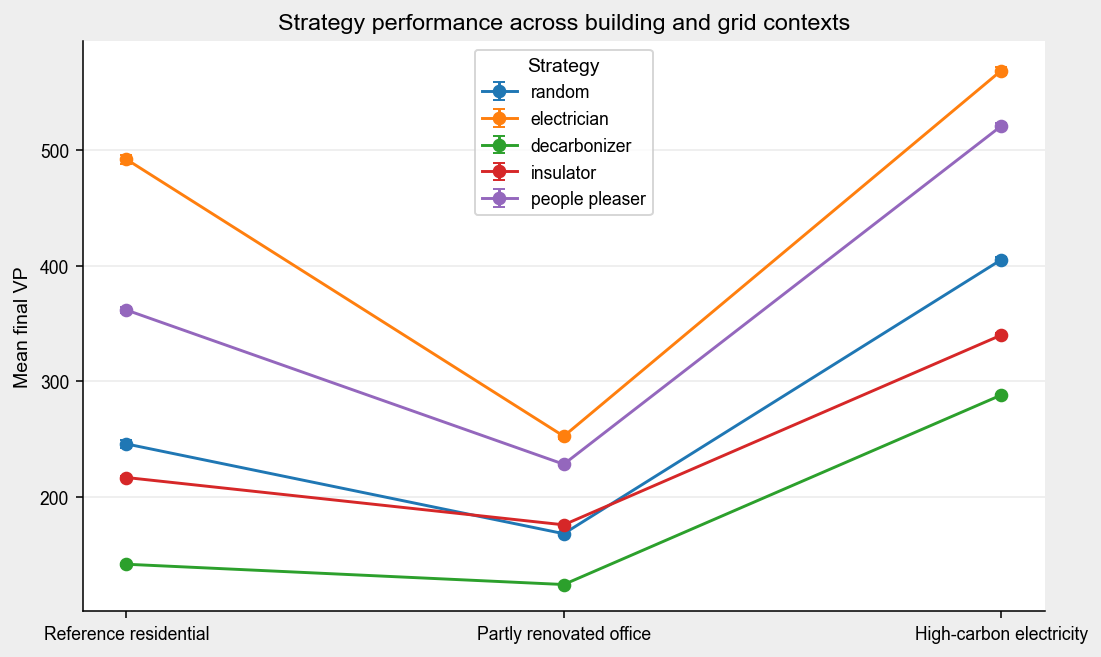

In [81]:
version_order = list(VERSION_PATHS)
strategy_order = list(STRATEGIES)

fig, ax = plt.subplots(figsize=(8, 4.8))

x = np.arange(len(version_order))

for strategy in strategy_order:
    data = (
        summary.loc[summary["strategy"] == strategy]
        .set_index("version")
        .reindex(version_order)
    )

    ax.errorbar(
        x,
        data["mean_vp"],
        yerr=data["ci95_vp"],
        marker="o",
        capsize=3,
        label=strategy,
    )

ax.set_xticks(
    x,
    [VERSION_LABELS[version] for version in version_order],
)
ax.set_ylabel("Mean final VP")
ax.set_xlabel("")
ax.set_title("Strategy performance across building and grid contexts")
ax.legend(title="Strategy")
ax.grid(axis="y", alpha=0.25)

fig.tight_layout()

if SAVE_FIGURES:
    save_figure(
        fig,
        FIGURE_DIR,
        "context_strategy_mean_vp.png",
    )

plt.show()


### Relative performance against the random baseline

Absolute VP shifts when the building or electricity scenario changes. The next figure therefore normalizes each strategy to the random strategy **within the same context**.

Positive values indicate an improvement over random. This is often the clearest figure for the paper if the purpose is to show context-dependent strategy value.

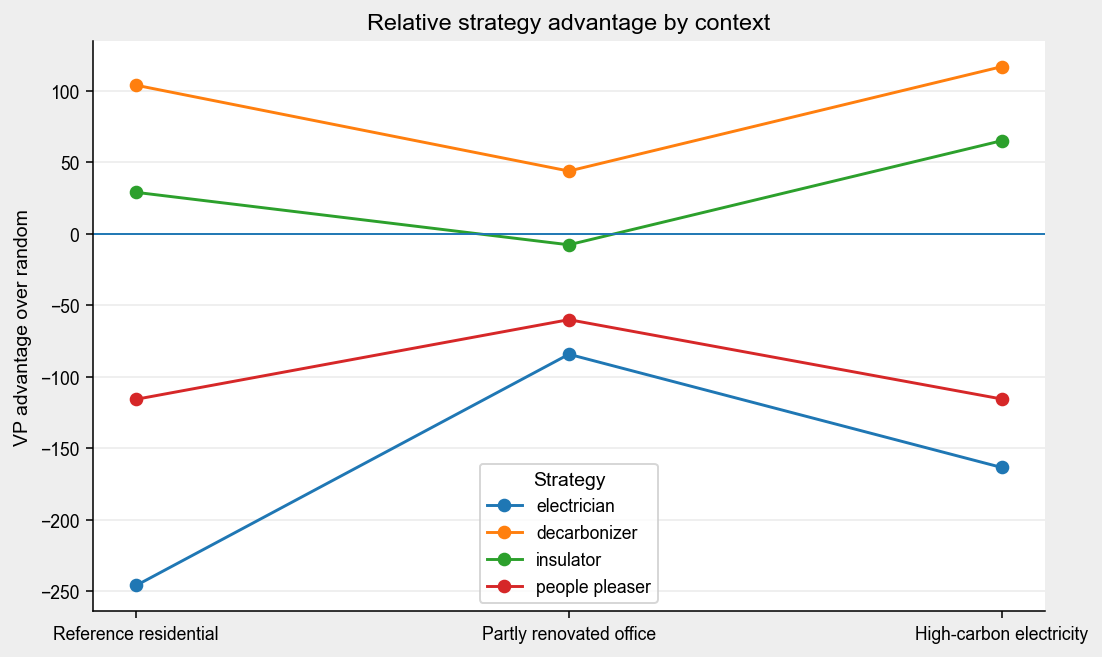

In [82]:
fig, ax = plt.subplots(figsize=(8, 4.8))

heuristics = [
    strategy
    for strategy in strategy_order
    if strategy != "random"
]

for strategy in heuristics:
    data = (
        summary.loc[summary["strategy"] == strategy]
        .set_index("version")
        .reindex(version_order)
    )

    ax.plot(
        x,
        data["relative_advantage_vs_random"],
        marker="o",
        label=strategy,
    )

ax.axhline(0, linewidth=1)
ax.set_xticks(
    x,
    [VERSION_LABELS[version] for version in version_order],
)
ax.set_ylabel("VP advantage over random")
ax.set_xlabel("")
ax.set_title("Relative strategy advantage by context")
ax.legend(title="Strategy")
ax.grid(axis="y", alpha=0.25)

fig.tight_layout()

if SAVE_FIGURES:
    save_figure(
        fig,
        FIGURE_DIR,
        "context_strategy_advantage_vs_random.png",
    )

plt.show()


## 7. Strategy rankings and robustness

The table below makes ranking changes explicit. A change in order between contexts is more informative for the paper than the expected shift in absolute VP.

The rank-correlation matrix provides a compact descriptive measure of how stable the strategy ordering is between contexts.

In [83]:
rank_table = (
    summary
    .pivot(
        index="strategy",
        columns="version",
        values="mean_vp",
    )
    .reindex(strategy_order)
    .reindex(columns=version_order)
    .rank(axis=0, method="min")
    .astype(int)
)

display(rank_table)

print("Spearman correlation of strategy rankings")
display(rank_table.corr(method="spearman"))


version,reference,office,high-carbon electricity
strategy,,,
random,3,2,3
electrician,5,5,5
decarbonizer,1,1,1
insulator,2,3,2
people pleaser,4,4,4


Spearman correlation of strategy rankings


version,reference,office,high-carbon electricity
version,,,
reference,1.0,0.9,1.0
office,0.9,1.0,0.9
high-carbon electricity,1.0,0.9,1.0


## 8. Completion and financial robustness

A strategy can achieve low VP by renovating aggressively while also increasing the risk of financial failure. Completion therefore remains an important secondary outcome.

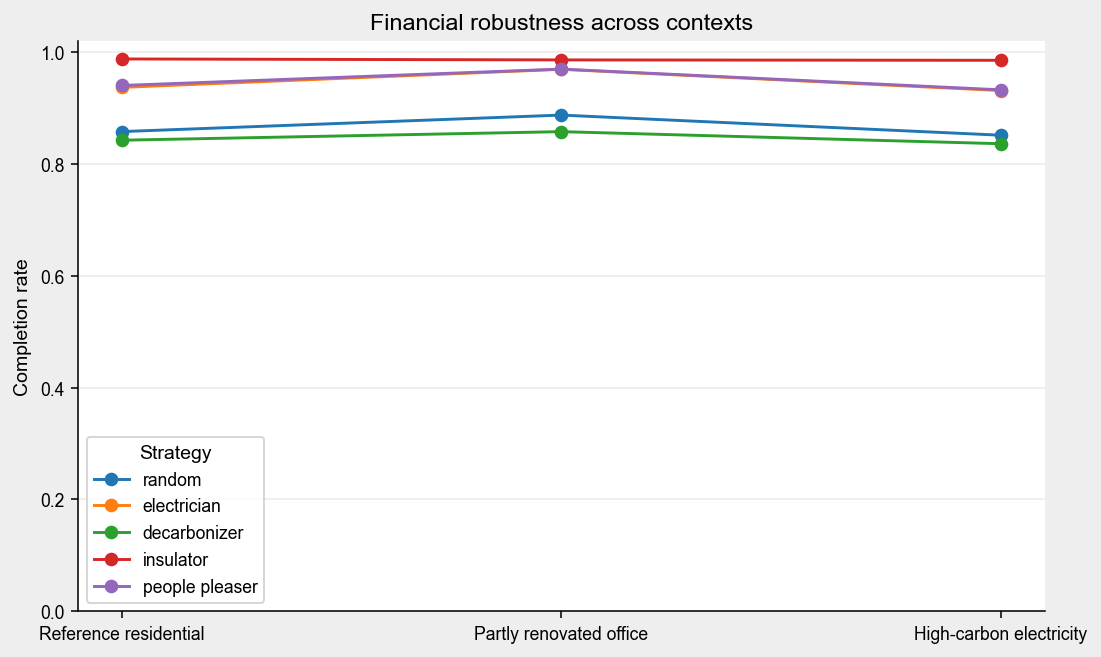

In [84]:
fig, ax = plt.subplots(figsize=(8, 4.8))

for strategy in strategy_order:
    data = (
        summary.loc[summary["strategy"] == strategy]
        .set_index("version")
        .reindex(version_order)
    )

    ax.plot(
        x,
        data["completion_rate"],
        marker="o",
        label=strategy,
    )

ax.set_xticks(
    x,
    [VERSION_LABELS[version] for version in version_order],
)
ax.set_ylim(0, 1.02)
ax.set_ylabel("Completion rate")
ax.set_xlabel("")
ax.set_title("Financial robustness across contexts")
ax.legend(title="Strategy")
ax.grid(axis="y", alpha=0.25)

fig.tight_layout()

if SAVE_FIGURES:
    save_figure(
        fig,
        FIGURE_DIR,
        "context_strategy_completion.png",
    )

plt.show()


## 9. Technology context-dependence under the random strategy

This supplementary analysis holds the decision strategy fixed and asks whether the descriptive VP association of individual technologies changes between contexts.

Using only the random strategy avoids mixing the building/grid-context effect with deliberate strategy preferences.

Positive VP lift means that games containing the technology have lower final VP than games in the **same context and same strategy** without it. The metric remains associative rather than causal.

In [85]:
random_games = all_games.loc[
    all_games["strategy"] == "random"
].copy()

card_results = []

for version, games in random_games.groupby("version"):

    result = card_analysis(
        games,
        game_data=game_data_by_version[version],
        elite_share=0.05,
    )

    result["version"] = version
    card_results.append(result)

card_results = pd.concat(
    card_results,
    ignore_index=True,
)

card_results.to_parquet(
    CARD_RESULTS_PATH,
    index=False,
)

card_context = (
    card_results
    .pivot_table(
        index="card",
        columns="version",
        values="vp_lift",
        aggfunc="mean",
    )
    .reindex(columns=version_order)
)

card_context.head()


version,reference,office,high-carbon electricity
card,,,
BESS_large,-7.398615,-20.900509,-1.249140
BESS_small,12.573838,-2.920037,11.448308
BIPV,-14.004751,-27.934914,-1.710169
add_balcony,-4.417337,-16.114220,-3.743458
balcony_pv,8.304834,7.801091,19.385456


In [86]:
# Add readable card labels and categories from the reference card set.

cards = pd.DataFrame(
    game_data_by_version["reference"]["cards"]
)

id_column = "card_id" if "card_id" in cards.columns else "id"

label_column = next(
    column
    for column in [
        "label_en",
        "Name EN",
        "Title EN",
        "Name",
        "Title",
    ]
    if column in cards.columns
)

category_column = next(
    (
        column
        for column in [
            "Slot/Stapel",
            "category",
        ]
        if column in cards.columns
    ),
    None,
)

columns = [id_column, label_column]

if category_column:
    columns.append(category_column)

card_info = (
    cards[columns]
    .drop_duplicates(id_column)
    .rename(columns={
        id_column: "card",
        label_column: "label",
        **(
            {category_column: "category"}
            if category_column
            else {}
        ),
    })
    .set_index("card")
)

card_context = card_context.join(card_info)

if "category" in card_context.columns:
    card_context = card_context.sort_values(
        ["category", "label"]
    )
else:
    card_context = card_context.sort_values("label")

card_context.head()


,reference,office,high-carbon electricity,label,category
card,,,,,
balcony_pv,8.304834,7.801091,19.385456,Balcony Power Plant,*Effizienz
car_sharing,11.794483,-0.538495,8.056681,Car Sharing,*Effizienz
electric_stove,2.540144,-5.330917,-14.114519,Electric stove,*Effizienz
BIPV,-14.004751,-27.934914,-1.710169,Facade integrated PV,*Effizienz
shower_water_heat_recovery,86.270247,55.028720,50.117460,Heat recovery from shower water,*Effizienz


### Cards whose apparent effect changes sign between contexts

This is a particularly useful descriptive result. A sign change means a technology is associated with lower VP in one context but higher VP in another, despite the same random decision policy.

That is evidence of **context dependence and interaction/path effects**, not a causal estimate of the technology's real-world performance.

In [87]:
vp_columns = version_order

card_context["min_vp_lift"] = (
    card_context[vp_columns].min(axis=1)
)
card_context["max_vp_lift"] = (
    card_context[vp_columns].max(axis=1)
)
card_context["vp_lift_range"] = (
    card_context["max_vp_lift"]
    - card_context["min_vp_lift"]
)
card_context["changes_sign"] = (
    (card_context["min_vp_lift"] < 0)
    & (card_context["max_vp_lift"] > 0)
)

sign_changes = (
    card_context.loc[card_context["changes_sign"]]
    .sort_values(
        "vp_lift_range",
        ascending=False,
    )
)

print(
    f"{len(sign_changes)} of {len(card_context)} cards "
    "change the sign of their descriptive VP lift "
    "between contexts."
)

display(
    sign_changes[
        [
            "label",
            *(
                ["category"]
                if "category" in sign_changes.columns
                else []
            ),
            *version_order,
            "vp_lift_range",
        ]
    ]
)


23 of 56 cards change the sign of their descriptive VP lift between contexts.


,label,category,reference,office,high-carbon electricity,vp_lift_range
card,,,,,,
biomass_boiler,Biomass boiler,Wärmeerzeugung,-11.949797,-4.100025,52.443388,64.393185
central_air_source_heat_pump,Central air source heat pump,Wärmeerzeugung,29.754205,32.137295,-8.969826,41.107121
underfloor_heating,Underfloor heating,Abgabe,3.347403,-20.966246,15.605507,36.571752
fan_assisted_radiators,Radiators with fans,Abgabe,19.889945,-1.962190,33.918852,35.881042
insulation_passivehouse_fossil,Passivehouse renovation conventional,Dämmung,-4.061434,-31.817638,3.158393,34.976031
window_repl_passivehouse,Complete replacement of the box window,Fenster,10.362430,-8.625191,21.931324,30.556515
conventional_facade_insulation_1,Conventional facade insulation,Dämmung,-0.538989,-12.242136,11.277068,23.519204
pv_medium,Medium-sized PV system,Dachnutzung,-0.284008,-1.017675,21.957328,22.975003
wall_heating,Wall heating,Abgabe,-3.666378,-13.461693,9.509261,22.970954


### Heatmap of technology VP lift across contexts

The diverging scale is centered at zero:

- red = negative association,
- white = approximately neutral,
- green = positive association.

For a compact publication figure, the code below displays the technologies with the largest cross-context variation. Increase `N_CARDS_HEATMAP` or remove the filter for the full supplementary heatmap.

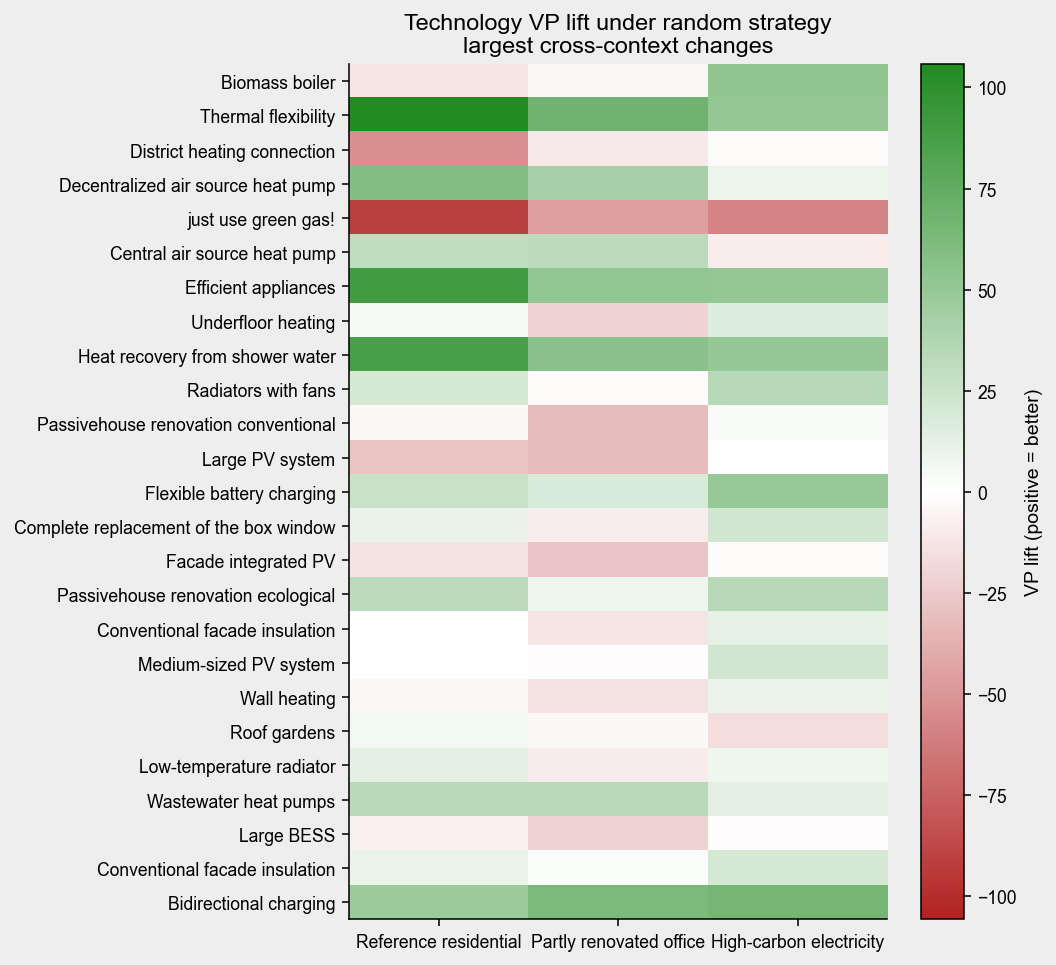

In [88]:
N_CARDS_HEATMAP = 25

heatmap_data = (
    card_context
    .nlargest(
        N_CARDS_HEATMAP,
        "vp_lift_range",
    )
)

matrix = heatmap_data[
    version_order
].to_numpy()

vmax = np.nanmax(np.abs(matrix))
norm = TwoSlopeNorm(
    vmin=-vmax,
    vcenter=0,
    vmax=vmax,
)

green_white_red = LinearSegmentedColormap.from_list(
    "red_white_green",
    ["firebrick", "white", "forestgreen"],
)

fig, ax = plt.subplots(
    figsize=(7.5, max(5, 0.28 * len(heatmap_data)))
)

image = ax.imshow(
    matrix,
    aspect="auto",
    cmap=green_white_red,
    norm=norm,
)

ax.set_xticks(
    np.arange(len(version_order)),
    [VERSION_LABELS[version] for version in version_order],
)

ax.set_yticks(
    np.arange(len(heatmap_data)),
    heatmap_data["label"],
)

ax.set_title(
    "Technology VP lift under random strategy\n"
    "largest cross-context changes"
)

colorbar = fig.colorbar(
    image,
    ax=ax,
)
colorbar.set_label(
    "VP lift (positive = better)"
)

fig.tight_layout()

if SAVE_FIGURES:
    save_figure(
        fig,
        FIGURE_DIR,
        "context_random_card_vp_lift.png",
    )

plt.show()


## 10. Interpretation checklist for the paper

The strongest result would be one or more of the following:

1. **Strategy ranking changes between contexts.**  
   This directly supports the claim that there is no universally optimal renovation pathway.

2. **Relative advantage over random changes strongly.**  
   Even if the ranking remains stable, a strategy becoming much more or less valuable under another starting state or grid pathway demonstrates context sensitivity.

3. **The office scenario weakens envelope-focused strategies and strengthens electricity-focused strategies.**  
   This would be consistent with the changed starting state, but should only be claimed if the simulation actually shows it.

4. **High-carbon electricity changes the value of electrification-related strategies or measures.**  
   Again, interpret the observed direction rather than assuming it in advance.

5. **Individual technology VP lift changes sign between contexts under the same random policy.**  
   This is strong descriptive evidence that card effectiveness is not intrinsic but depends on the surrounding building and energy-system state.

6. **Completion-rate effects should be reported alongside VP.**  
   A low-emission strategy that frequently exhausts the budget represents a different trade-off from one that achieves slightly higher VP but robustly completes all rounds.

For the main paper, the most useful outputs are likely:

- the **strategy × context mean-VP figure**,
- the **relative advantage over random figure** if rankings are visually hard to compare,
- and optionally the **technology VP-lift heatmap** as supplementary evidence of context dependence.